When exploring a large set of documents -- such as Wikipedia, news articles, StackOverflow, etc. -- it can be useful to get a list of related material. To find relevant documents you typically
* Decide on a notion of similarity
* Find the documents that are most similar

In the assignment you will
* Gain intuition for different notions of similarity and practice finding similar documents.
* Explore the tradeoffs with representing documents using raw word counts and TF-IDF
* Explore the behavior of different distance metrics by looking at the Wikipedia pages most similar to President Obama’s page.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

## Load Wikipedia dataset

We will be using the dataset of abridged Wikipedia pages. Each element of the dataset consists of a link to the wikipedia article, the name of the person, and the text of the article (in lowercase).  

In [2]:
wiki = pd.read_csv('people_wiki.csv')
wiki.head()

,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...


If you want to check whether the text on the webpage agrees with the one here, you can display it with the following code:

In [ ]:
# from IPython.display import HTML
# print(wiki['text'][0])
# HTML(url=wiki['URI'][0])

## Ex. 1: Extract word count vectors

As we have seen in Assignment 4, we can extract word count vectors using `CountVectorizer` function.
- make sure you include words of unit length by using the parameter: `token_pattern=r"(?u)\b\w+\b"`
- do not use any stopwords
- take 10000 most frequent words in the corpus
- explicitly take all the words independent of in how many documents they occur
- obtain the matrix of word counts

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    token_pattern=r"(?u)\b\w+\b",  # include unit-length words
    stop_words=None,               # no stopwords
    max_features=10000,            # 10k most frequent words
    min_df=1,                      # take all words regardless of document frequency
    max_df=1.0
)

WCmatrix = vectorizer.fit_transform(wiki['text'])

## Ex. 2: Find nearest neighbors

**a)** Start by finding the nearest neighbors of the Barack Obama page using the above word count matrix to represent the articles and **Euclidean** distance to measure distance.
Save the distances in `wiki['BO-eucl']` and look at the top 10 nearest neighbors.

In [7]:
# One can use the following:
    # from sklearn.neighbors import NearestNeighbors
    # nbrs = NearestNeighbors(n_neighbors=3, algorithm='brute',metric='euclidean').fit(X.toarray())
    # distances, indices = nbrs.kneighbors(X.toarray())
# but here let's use:
from sklearn.metrics import pairwise_distances

dist = pairwise_distances(
    WCmatrix,
    WCmatrix[wiki[wiki['name'] == 'Barack Obama'].index[0]],
    metric='euclidean'
)
wiki['BO-eucl'] = dist.flatten()
wiki.sort_values('BO-eucl').head(10)[['name', 'BO-eucl']]

,name,BO-eucl
35817,Barack Obama,0.000000
24478,Joe Biden,31.352831
28447,George W. Bush,33.660065
48202,Tony Vaccaro,33.749074
14754,Mitt Romney,34.365681
31423,Walter Mondale,34.438351
36364,Don Bonker,34.612137
13229,Francisco Barrio,34.684290
35357,Lawrence Summers,35.397740
22745,Wynn Normington Hugh-Jones,35.454196


,URI,name,text,BO-eucl
35817,<http://dbpedia.org/resource/Barack_Obama>,Barack Obama,barack hussein obama ii brk husen bm born augu...,0.000000
24478,<http://dbpedia.org/resource/Joe_Biden>,Joe Biden,joseph robinette joe biden jr dosf rbnt badn b...,31.336879
28447,<http://dbpedia.org/resource/George_W._Bush>,George W. Bush,george walker bush born july 6 1946 is an amer...,33.645208
48202,<http://dbpedia.org/resource/Tony_Vaccaro>,Tony Vaccaro,michelantonio celestino onofrio vaccaro born d...,33.734256
14754,<http://dbpedia.org/resource/Mitt_Romney>,Mitt Romney,willard mitt romney born march 12 1947 is an a...,34.351128
31423,<http://dbpedia.org/resource/Walter_Mondale>,Walter Mondale,walter frederick fritz mondale born january 5 ...,34.423829
36364,<http://dbpedia.org/resource/Don_Bonker>,Don Bonker,don leroy bonker born march 7 1937 in denver c...,34.597688
13229,<http://dbpedia.org/resource/Francisco_Barrio>,Francisco Barrio,francisco javier barrio terrazas born november...,34.669872
35357,<http://dbpedia.org/resource/Lawrence_Summers>,Lawrence Summers,lawrence henry larry summers born november 30 ...,35.383612
25258,<http://dbpedia.org/resource/Marc_Ravalomanana>,Marc Ravalomanana,marc ravalomanana malagasy ravalumanan born 12...,35.440090


**b)** Measure the pairwise distance between the Wikipedia pages of Barack Obama, George W. Bush, and Joe Biden. Which of the three pairs has the smallest distance?

In [8]:
# Your code goes here
names = ['Barack Obama', 'George W. Bush', 'Joe Biden']
indices = [wiki[wiki['name'] == name].index[0] for name in names]

from sklearn.metrics import pairwise_distances

dist_matrix = pairwise_distances(
    WCmatrix[indices],
    metric='euclidean'
)

dist_matrix
pd.DataFrame(dist_matrix, index=names, columns=names)

,Barack Obama,George W. Bush,Joe Biden
Barack Obama,0.000000,33.660065,31.352831
George W. Bush,33.660065,0.000000,30.919250
Joe Biden,31.352831,30.919250,0.000000


All of the 10 people from **a)** are politicians, but about half of them have rather tenuous connections with Obama, other than the fact that they are politicians, e.g.,

* Francisco Barrio is a Mexican politician, and a former governor of Chihuahua.
* Walter Mondale and Don Bonker are Democrats who made their career in late 1970s.

Nearest neighbors with raw word counts got some things right, showing all politicians in the query result, but missed finer and important details.

**c)** Let's find out why Francisco Barrio was considered a close neighbor of Obama.
To do this, look at the most frequently used words in each of Barack Obama and Francisco Barrio's pages.

In [9]:
def top_words(name):
    """
    Get a table of the most frequent words in the given person's wikipedia page.
    """
    idx = wiki[wiki['name'] == name].index[0]

    word_counts = WCmatrix[idx].toarray().flatten()
    words = vectorizer.get_feature_names_out()

    df = pd.DataFrame({
        'word': words,
        'count': word_counts
    })

    return df.sort_values(by='count', ascending=False)

In [10]:
obama_words = top_words('Barack Obama')
obama_words

,word,count
9062,the,40
4613,in,30
720,and,21
6377,of,18
9161,to,14
...,...,...
3379,europa,0
3380,europe,0
3381,european,0
3382,europes,0


In [11]:
barrio_words = top_words('Francisco Barrio')
barrio_words

,word,count
9062,the,36
6377,of,24
720,and,18
4613,in,17
4282,he,10
...,...,...
3367,et,0
3368,etc,0
3369,eternal,0
3370,ethical,0


**d)** Extract the list of most frequent **common** words that appear in both Obama's and Barrio's documents and display the five words that appear most often in Barrio's article.

Use a dataframe operation known as **join**. The **join** operation is very useful when it comes to playing around with data: it lets you combine the content of two tables using a shared column (in this case, the index column of words). See [the documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.join.html) for more details.

In [14]:
obama_words = top_words('Barack Obama').set_index('word')
barrio_words = top_words('Francisco Barrio').set_index('word')

common_words = obama_words.join(
    barrio_words,
    how='inner',
    lsuffix='_Obama',
    rsuffix='_Barrio'
)

common_words.sort_values(
    by='count_Barrio',
    ascending=False
).head(5)

,count_Obama,count_Barrio
word,,
the,40,36
of,18,24
and,21,18
in,30,17
he,7,10


Collect all words that appear both in Barack Obama and George W. Bush pages.  Out of those words, find the 10 words that show up most often in Obama's page.

In [15]:
obama_words = top_words('Barack Obama').set_index('word')
bush_words = top_words('George W. Bush').set_index('word')

common_words = obama_words.join(
    bush_words,
    how='inner',
    lsuffix='_Obama',
    rsuffix='_Bush'
)

common_words.sort_values(
    by='count_Obama',
    ascending=False
).head(10)

,count_Obama,count_Bush
word,,
the,40,39
in,30,22
and,21,14
of,18,14
to,14,11
his,11,6
obama,9,0
act,8,3
a,7,6


**Note.** Even though common words are swamping out important subtle differences, commonalities in rarer political words still matter on the margin. This is why politicians are being listed in the query result instead of musicians, for example. In the next subsection, we will introduce a different metric that will place greater emphasis on those rarer words.

**e)** Among the words that appear in both Barack Obama and Francisco Barrio, take the 15 that appear most frequently in Obama. How many of the articles in the Wikipedia dataset contain all of those 15 words? Which are they?

In [18]:
common_words = obama_words.join(
    barrio_words,
    how='inner',
    lsuffix='_Obama',
    rsuffix='_Barrio'
)

top15_words = common_words.sort_values(
    by='count_Obama',
    ascending=False
).head(15).index.tolist()

word_to_ind = {v: i for i, v in enumerate(vectorizer.get_feature_names_out())}
word_indices = [word_to_ind[w] for w in top15_words]

X = WCmatrix[:, word_indices]
articles = (X.toarray() > 0).all(axis=1)

articles.sum()

np.int64(2)

In [19]:
wiki[articles]['name']

,name
24478,Joe Biden
35817,Barack Obama


## Ex. 3: TF-IDF to the rescue

Much of the perceived commonalities between Obama and Barrio were due to occurrences of extremely frequent words, such as "the", "and", and "his". So nearest neighbors is recommending plausible results sometimes for the wrong reasons.

To retrieve articles that are more relevant, we should focus more on rare words that don't happen in every article. **TF-IDF** (term frequency–inverse document frequency) is a feature representation that penalizes words that are too common.

**a)** Repeat the search for the 10 nearest neighbors of Barack Obama with Euclidean distance of TF-IDF. This time do not limit to only 10000 most frequent words, but take all of them.

In [22]:
# We could use:
    # from sklearn.feature_extraction.text import TfidfVectorizer
# but since we already know how to compute CountVectorizer, let's use:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    token_pattern=r"(?u)\b\w+\b",  # uwzględnij słowa 1-znakowe
    stop_words=None,
    min_df=1,
    max_df=1.0
)

WCmatrix = vectorizer.fit_transform(wiki['text'])

from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer(
    smooth_idf=False,
    norm=None
)

TFIDFmatrix = tfidf.fit_transform(WCmatrix)

In [23]:
from sklearn.metrics import pairwise_distances

obama_idx = wiki[wiki['name'] == 'Barack Obama'].index[0]

dist = pairwise_distances(
    TFIDFmatrix,
    TFIDFmatrix[obama_idx],
    metric='euclidean'
)
wiki['BO-eucl-TF-IDF'] = dist.flatten()

wiki.sort_values('BO-eucl-TF-IDF').head(10)[['name', 'BO-eucl-TF-IDF']]

,name,BO-eucl-TF-IDF
35817,Barack Obama,0.000000
38376,Samantha Power,139.364493
46811,Jeff Sessions,139.757740
7914,Phil Schiliro,139.812175
38714,Eric Stern (politician),140.450064
6507,Bob Menendez,141.661111
44681,Jesse Lee (politician),142.342440
6796,Eric Holder,142.490179
38495,Barney Frank,142.581337
56008,Nathan Cullen,142.751073


Let's determine whether this list makes sense.
* With a notable exception of Nathan Cullen, the other 8 are all American politicians who are contemporaries of Barack Obama.
* Phil Schiliro, Jesse Lee, Samantha Power, Eric Stern, Eric Holder worked for Obama.

Clearly, the results are more plausible with the use of TF-IDF. Let's take a look at the word vector for Obama and Schilirio's pages. Notice that TF-IDF representation assigns a weight to each word. This weight captures relative importance of that word in the document.

**b)** Sort the words in Obama's article by their TF-IDF weights; do the same for Schiliro's article as well.
Using the **join** operation we learned earlier, compute the common words shared by Obama's and Schiliro's articles.
Sort the common words by their TF-IDF weights in Obama's document.

In [25]:
def top_words_tf_idf(name):
    """
    Get a table of the largest tf-idf words in the given person's wikipedia page.
    """
    idx = wiki[wiki['name'] == name].index[0]

    tfidf_values = TFIDFmatrix[idx].toarray().flatten()
    words = vectorizer.get_feature_names_out()

    df = pd.DataFrame({
        'word': words,
        'tf-idf': tfidf_values
    })

    return df.sort_values(by='tf-idf', ascending=False)

In [29]:
obama_tf_idf = top_words_tf_idf('Barack Obama')
schiliro_tf_idf = top_words_tf_idf('Phil Schiliro')

common_words = (
    obama_tf_idf.set_index('word')
    .join(
        schiliro_tf_idf.set_index('word'),
        how='inner',
        lsuffix='_Obama',
        rsuffix='_Schiliro'
    )
    .sort_values(by='tf-idf_Obama', ascending=False)
)

common_words.head(10)

,tf-idf_Obama,tf-idf_Schiliro
word,,
obama,52.295653,11.621256
the,40.004063,10.001016
act,35.678223,0.000000
in,30.028962,5.004827
iraq,21.747379,0.000000
and,21.015648,6.004471
law,20.722936,10.361468
control,18.887061,0.000000
of,18.074811,9.037406


**c)** Among the words that appear in both Barack Obama and Phil Schiliro, take the 15 that have largest weights in Obama. How many of the articles in the Wikipedia dataset contain all of those 15 words? Which are they?

In [31]:
# poprawne pobranie wszystkich słów jako słownika (słowo → indeks kolumny)
word_to_ind = {v: i for i, v in enumerate(vectorizer.get_feature_names_out())}

# 15 najważniejszych słów wspólnych
top15_words = common_words.head(15).index.tolist()
word_indices = [word_to_ind[w] for w in top15_words]

# wybieramy kolumny TF-IDF odpowiadające tym słowom
X = TFIDFmatrix[:, word_indices]

# sprawdzamy, które artykuły zawierają wszystkie te 15 słów
articles = (X.toarray() > 0).all(axis=1)

# ile artykułów spełnia warunek
articles.sum()

# które to artykuły
wiki[articles]['name']


,name
35817,Barack Obama


In [32]:
wiki[articles]['name']

,name
35817,Barack Obama


Notice the huge difference in this calculation using TF-IDF scores instead  of raw word counts. We've eliminated noise arising from extremely common words.

## Ex. 4: Choosing metrics

**a)** Compute the Euclidean distance between TF-IDF features of Obama and Biden.

In [33]:
from sklearn.metrics import pairwise_distances

# indeksy Obamy i Bidena
obama_idx = wiki[wiki['name'] == 'Barack Obama'].index[0]
biden_idx = wiki[wiki['name'] == 'Joe Biden'].index[0]

# obliczenie odległości euklidesowej
dist = pairwise_distances(
    TFIDFmatrix[obama_idx],
    TFIDFmatrix[biden_idx],
    metric='euclidean'
)[0][0]

dist

np.float64(148.77845413077898)

The distance is larger than the distances we found for the 10 nearest neighbors, which we repeat here for readability:

In [34]:
wiki.sort_values(by='BO-eucl-TF-IDF',ascending=True)[['name','BO-eucl-TF-IDF']][0:10]

,name,BO-eucl-TF-IDF
35817,Barack Obama,0.000000
38376,Samantha Power,139.364493
46811,Jeff Sessions,139.757740
7914,Phil Schiliro,139.812175
38714,Eric Stern (politician),140.450064
6507,Bob Menendez,141.661111
44681,Jesse Lee (politician),142.342440
6796,Eric Holder,142.490179
38495,Barney Frank,142.581337
56008,Nathan Cullen,142.751073


But one may wonder, is Biden's article that different from Obama's, more so than, say, Schiliro's? It turns out that, when we compute nearest neighbors using the Euclidean distances, we unwittingly favor short articles over long ones.

**b)** Let us compute the length of each Wikipedia document, and examine the document lengths for the 100 nearest neighbors to Obama's page. To compute text length use the same splitting rules you used in `vectorizer`.

In [37]:
import re

token_pattern = re.compile(r"(?u)\b\w+\b")

tokenizer = lambda text: token_pattern.findall(text)

def compute_length(row):
    return len(tokenizer(row['text']))
wiki['length'] = wiki.apply(compute_length, axis=1)

In [38]:
nearest_100 = wiki.sort_values('BO-eucl-TF-IDF').head(100)
nearest_100['length'].describe()

,length
count,100.000000
mean,227.960000
std,40.154731
min,201.000000
25%,207.000000
50%,217.500000
75%,232.250000
max,540.000000


**c)** To see how these document lengths compare to the lengths of other documents in the corpus, make a histogram of the document lengths of Obama's 100 nearest neighbors and compare to a histogram of document lengths for all documents.

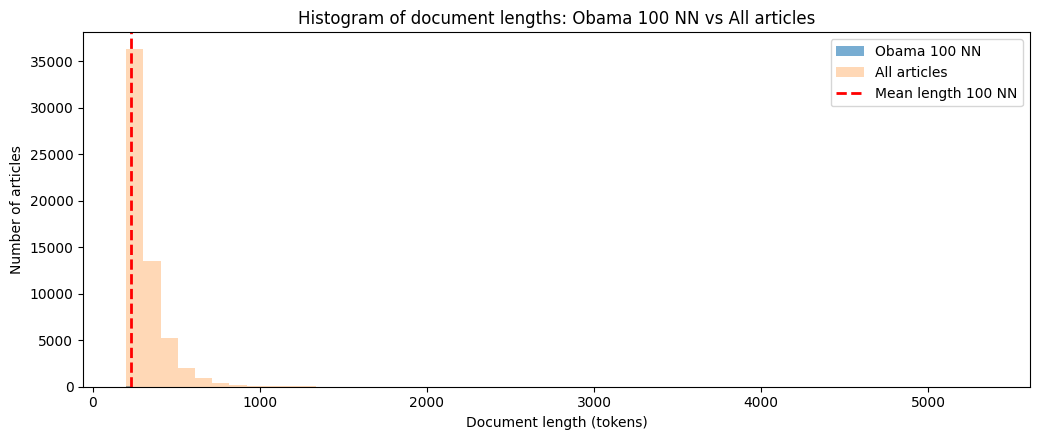

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10.5, 4.5))

# Histogram długości dla 100 najbliższych sąsiadów Obamy
plt.hist(
    wiki.sort_values('BO-eucl-TF-IDF').head(100)['length'],
    bins=20, alpha=0.6, label='Obama 100 NN'
)

# Histogram długości dla wszystkich artykułów
plt.hist(
    wiki['length'],
    bins=50, alpha=0.3, label='All articles'
)

# Linia pionowa dla średniej długości artykułów Obamy 100 NN
plt.axvline(
    wiki.sort_values('BO-eucl-TF-IDF').head(100)['length'].mean(),
    color='red', linestyle='dashed', linewidth=2, label='Mean length 100 NN'
)

plt.xlabel('Document length (tokens)')
plt.ylabel('Number of articles')
plt.title('Histogram of document lengths: Obama 100 NN vs All articles')
plt.legend()
plt.tight_layout()
plt.show()

Relative to the rest of Wikipedia, nearest neighbors of Obama are overwhemingly short, most of them being shorter than 300 words. The bias towards short articles is not appropriate in this application as there is really no reason to  favor short articles over long articles (they are all Wikipedia articles, after all). Many of the Wikipedia articles are 300 words or more, and both Obama and Biden are over 300 words long.

**Note**: For the interest of computation time, the dataset given here contains _excerpts_ of the articles rather than full text. For instance, the actual Wikipedia article about Obama is around 25000 words. Do not be surprised by the low numbers shown in the histogram.

**Note:** Both word-count features and TF-IDF are proportional to word frequencies. While TF-IDF penalizes very common words, longer articles tend to have longer TF-IDF vectors simply because they have more words in them.

To remove this bias, we turn to **cosine distances**:
$$
d(\mathbf{x},\mathbf{y}) = 1 - \frac{\mathbf{x}^T\mathbf{y}}{\|\mathbf{x}\| \|\mathbf{y}\|}
$$
Cosine distances let us compare word distributions of two articles of varying lengths.

**d)** Train a new nearest neighbor model, this time with cosine distances.  Then repeat the search for Obama's 100 nearest neighbors and make a plot to better visualize the effect of having used cosine distance in place of Euclidean on our TF-IDF vectors.

In [44]:
from sklearn.neighbors import NearestNeighbors

# Tworzymy model
nearest_neighbors_cosine = NearestNeighbors(
    n_neighbors=100,
    algorithm='brute',
    metric='cosine'
)

# Dopasowanie do całej macierzy TF-IDF
nearest_neighbors_cosine.fit(TFIDFmatrix)

obama_idx = wiki[wiki['name'] == 'Barack Obama'].index[0]

# Znalezienie 100 najbliższych sąsiadów
distances, indices = nearest_neighbors_cosine.kneighbors(TFIDFmatrix[obama_idx])

From a glance at the above table, things look better.  For example, we now see Joe Biden as Barack Obama's nearest neighbor!  We also see Hillary Clinton on the list.  This list looks even more plausible as nearest neighbors of Barack Obama.

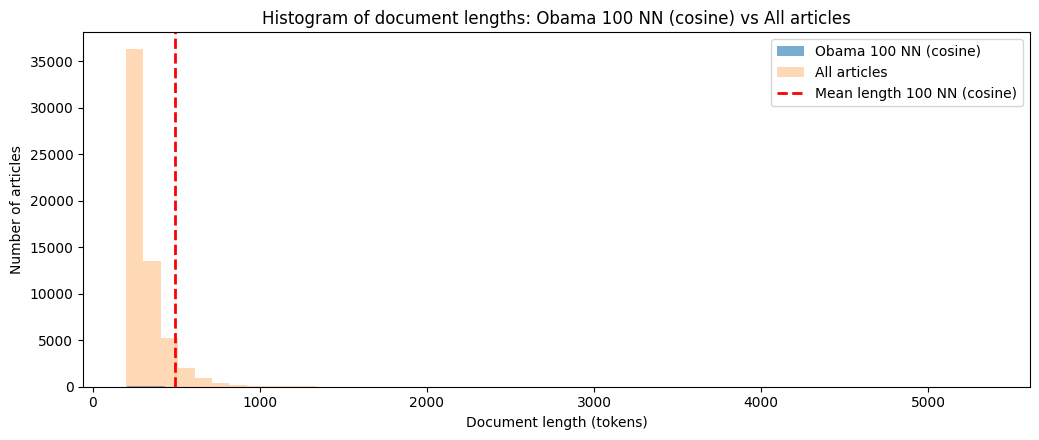

In [43]:
nearest_100_cosine = wiki.iloc[indices[0]]

# Wykres
plt.figure(figsize=(10.5, 4.5))

plt.hist(
    nearest_100_cosine['length'],
    bins=20,
    alpha=0.6,
    label='Obama 100 NN (cosine)'
)

plt.hist(
    wiki['length'],
    bins=50,
    alpha=0.3,
    label='All articles'
)

plt.axvline(
    nearest_100_cosine['length'].mean(),
    color='red', linestyle='dashed', linewidth=2,
    label='Mean length 100 NN (cosine)'
)

plt.xlabel('Document length (tokens)')
plt.ylabel('Number of articles')
plt.title('Histogram of document lengths: Obama 100 NN (cosine) vs All articles')
plt.legend()
plt.tight_layout()
plt.show()

Indeed, the 100 nearest neighbors using cosine distance provide a sampling across the range of document lengths, rather than just short articles like Euclidean distance provided.

**Moral of the story**: In deciding the features and distance measures, check if they produce results that make sense for your particular application.

## Ex. 5: Problem with cosine distances: tweets vs. long articles

Happily ever after? Not so fast. Cosine distances ignore all document lengths, which may be great in certain situations but not in others. For instance, consider the following (admittedly contrived) example.

```
+--------------------------------------------------------+
|                                             +--------+ |
|  One that shall not be named                | Follow | |
|  @username                                  +--------+ |
|                                                        |
|  Democratic governments control law in response to     |
|  popular act.                                          |
|                                                        |
|  8:05 AM - 16 May 2016                                 |
|                                                        |
|  Reply   Retweet (1,332)   Like (300)                  |
|                                                        |
+--------------------------------------------------------+
```

**a)** Transform the tweet into TF-IDF features, using the fit to the Wikipedia dataset. (That is, let's treat this tweet as an article in our Wikipedia dataset and see what happens.) How similar is this tweet to Barack Obama's Wikipedia article?

In [45]:
# Tworzymy dataframe z tweetem
df = pd.DataFrame({'text': ['democratic governments control law in response to popular act']})

# Zamiana na wektory słów zgodnie z CountVectorizer z Wikipedia
tweet_counts = vectorizer.transform(df['text'])

#Transformacja do TF-IDF (używając fit transform z Wikipedii)
from sklearn.preprocessing import normalize

tweet_tfidf = tfidf.transform(tweet_counts)

#Obliczenie podobieństwa (cosine) do artykułu Baracka Obamy
from sklearn.metrics.pairwise import cosine_similarity

obama_idx = wiki[wiki['name'] == 'Barack Obama'].index[0]

similarity = cosine_similarity(
    tweet_tfidf,
    TFIDFmatrix[obama_idx]
)[0][0]

similarity

np.float64(0.3013354650209325)

Let's compare this tweet's TF-IDF vectors  to Barack Obama's Wikipedia entry.

In [46]:
obama_tf_idf

,word,tf-idf
358582,obama,52.295653
488178,the,40.004063
45084,act,35.678223
251924,in,30.028962
259239,iraq,21.747379
...,...,...
182869,equinoxes,0.000000
182870,equip,0.000000
182871,equipaje,0.000000
182872,equipe,0.000000


**b)** Now, compute the cosine distance between the Barack Obama article and this tweet:

In [47]:
from sklearn.metrics.pairwise import cosine_distances # for one pair of samples we can just use this function

obama_idx = wiki[wiki['name'] == 'Barack Obama'].index[0]

# Obliczenie cosine distance między tweetem a artykułem Obamy
distance = cosine_distances(
    tweet_tfidf,
    TFIDFmatrix[obama_idx]
)[0][0]

distance

np.float64(0.6986645349790674)

Let's compare this distance to the distance between the Barack Obama article and all of its Wikipedia nearest neighbors:

In [49]:
# indeks Obamy
obama_idx = wiki[wiki['name'] == 'Barack Obama'].index[0]

# znajdź 100 najbliższych sąsiadów (lub mniej, jeśli chcesz tylko top 23)
distances, indices = nearest_neighbors_cosine.kneighbors(TFIDFmatrix[obama_idx])

# top 23 najbliższych sąsiadów
top23_indices = indices[0][:23]
top23_distances = distances[0][:23]

# odpowiednie wiersze w dataframe
nearest_23 = wiki.iloc[top23_indices]

nearest_23[['name']]
top23_distances

array([1.11022302e-15, 5.72724821e-01, 6.16148742e-01, 6.25796573e-01,
       6.51475148e-01, 6.59478267e-01, 6.61645150e-01, 6.66690456e-01,
       6.71225784e-01, 6.73299778e-01, 6.73581456e-01, 6.75259544e-01,
       6.77451027e-01, 6.79724258e-01, 6.81387003e-01, 6.81761254e-01,
       6.87271795e-01, 6.92701097e-01, 6.96580624e-01, 6.96641807e-01,
       6.98133018e-01, 6.98548625e-01, 6.98799500e-01])

With cosine distances, the tweet is "nearer" to Barack Obama than most people! If someone is reading the Barack Obama Wikipedia page, would you want to recommend they read this tweet?
In practice, it is common to enforce maximum or minimum document lengths. After all, when someone is reading a long article from _The Atlantic_, you wouldn't recommend him/her a tweet.